In [29]:
import pandas as pd

# Load the CSV
df = pd.read_csv(
    "leakage_outputs/ibm_brisbane_per_shot_ZX.csv",
    dtype={"syndrome_Z": str, "syndrome_X": str}
)

# Create a repeating sequence of 0/1 blocks, each of size 4096
df["syndrome"] = df["syndrome_Z"] + df["syndrome_X"]
df["round"] = (df.index // 4096) % 2
df["state_id"] = round(df["theta"], 2).astype(str) + "_" + round(df["phi"],2).astype(str)

# Save back to CSV (optional)
df.to_csv("ibm_brisbane_per_shot_ZX_with_round.csv", index=False)

print(df.tail())


            backend     code     theta       phi    syndrome_Z    syndrome_X  \
32763  ibm_brisbane  surface  1.570796  3.141593  011001000010  111001000000   
32764  ibm_brisbane  surface  1.570796  3.141593  110000010011  011010000011   
32765  ibm_brisbane  surface  1.570796  3.141593  110000010000  000000010000   
32766  ibm_brisbane  surface  1.570796  3.141593  000101010100  011000111000   
32767  ibm_brisbane  surface  1.570796  3.141593  010000000011  001101111000   

                       syndrome  round   state_id  
32763  011001000010111001000000      1  1.57_3.14  
32764  110000010011011010000011      1  1.57_3.14  
32765  110000010000000000010000      1  1.57_3.14  
32766  000101010100011000111000      1  1.57_3.14  
32767  010000000011001101111000      1  1.57_3.14  


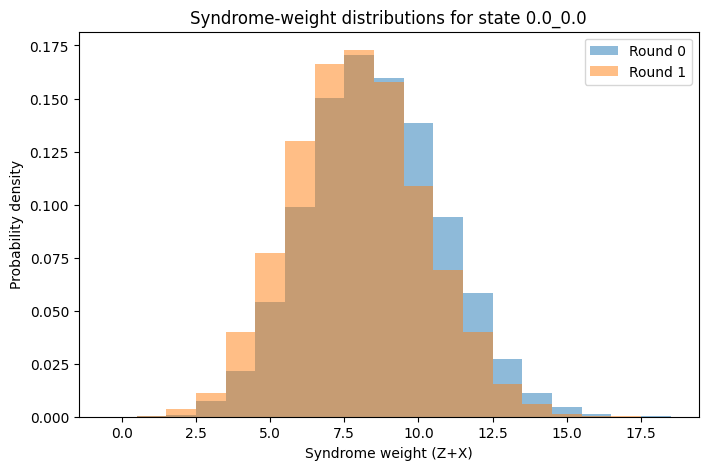

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Compute syndrome weights
df["wZ"] = df["syndrome_Z"].apply(lambda s: s.count("1"))
df["wX"] = df["syndrome_X"].apply(lambda s: s.count("1"))
df["wZX"] = df["syndrome"].apply(lambda s: s.count("1"))

# Choose one prepared state (same θ, φ)
state = "0.0_0.0"
subset = df[df["state_id"] == state]

# Separate rounds
round0 = subset[subset["round"] == 0]
round1 = subset[subset["round"] == 1]

# Plot histograms
plt.figure(figsize=(8,5))
bins = np.arange(0, max(df["wZX"])+2) - 0.5  # nice integer binning
plt.hist(round0["wZX"], bins=bins, alpha=0.5, label="Round 0", density=True)
plt.hist(round1["wZX"], bins=bins, alpha=0.5, label="Round 1", density=True)
plt.xlabel("Syndrome weight (Z+X)")
plt.ylabel("Probability density")
plt.title(f"Syndrome-weight distributions for state {state}")
plt.legend()
plt.show()


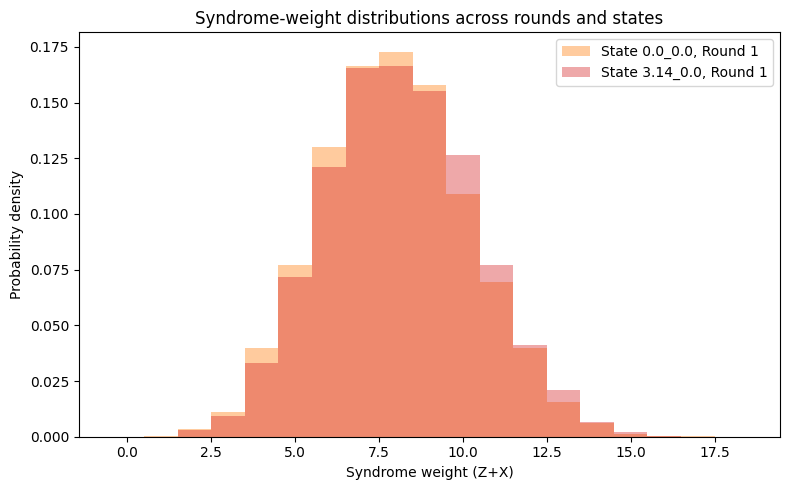

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon

# Ensure weights exist
if "wZX" not in df.columns:
    df["wZ"] = df["syndrome_Z"].apply(lambda s: s.count("1"))
    df["wX"] = df["syndrome_X"].apply(lambda s: s.count("1"))
    df["wZX"] = df["syndrome"].apply(lambda s: s.count("1"))

# Define your two target states
state1 = "0.0_0.0"
state2 = "3.14_0.0"

# Subsets
s1_r0 = df[(df["state_id"] == state1) & (df["round"] == 0)]
s1_r1 = df[(df["state_id"] == state1) & (df["round"] == 1)]
s2_r0 = df[(df["state_id"] == state2) & (df["round"] == 0)]
s2_r1 = df[(df["state_id"] == state2) & (df["round"] == 1)]

# Define bins based on full dataset
bins = np.arange(0, max(df["wZX"]) + 2) - 0.5

# Plot all four on the same axes
plt.figure(figsize=(8,5))
plt.hist(s1_r0["wZX"], bins=bins, alpha=0.4, density=True, label=f"State {state1}, Round 0", color="C0")
plt.hist(s1_r1["wZX"], bins=bins, alpha=0.4, density=True, label=f"State {state1}, Round 1", color="C1")
plt.hist(s2_r0["wZX"], bins=bins, alpha=0.4, density=True, label=f"State {state2}, Round 0", color="C2")
plt.hist(s2_r1["wZX"], bins=bins, alpha=0.4, density=True, label=f"State {state2}, Round 1", color="C3")

plt.xlabel("Syndrome weight (Z+X)")
plt.ylabel("Probability density")
plt.title("Syndrome-weight distributions across rounds and states")
plt.legend()
plt.tight_layout()
plt.show()


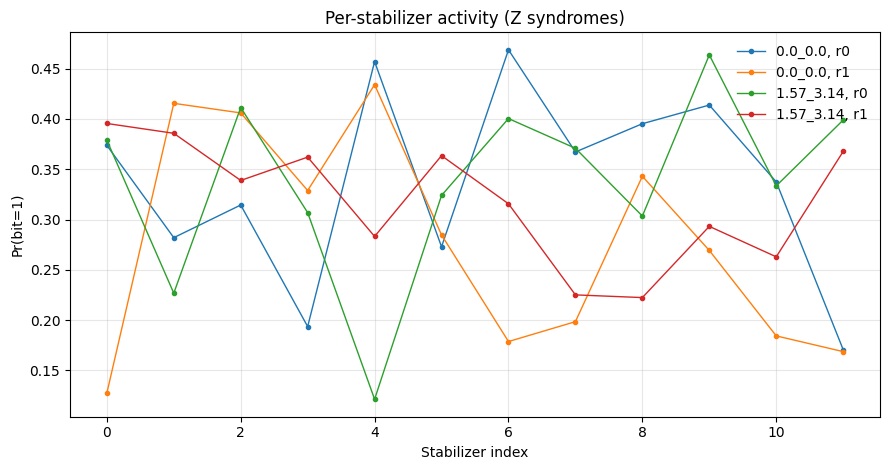

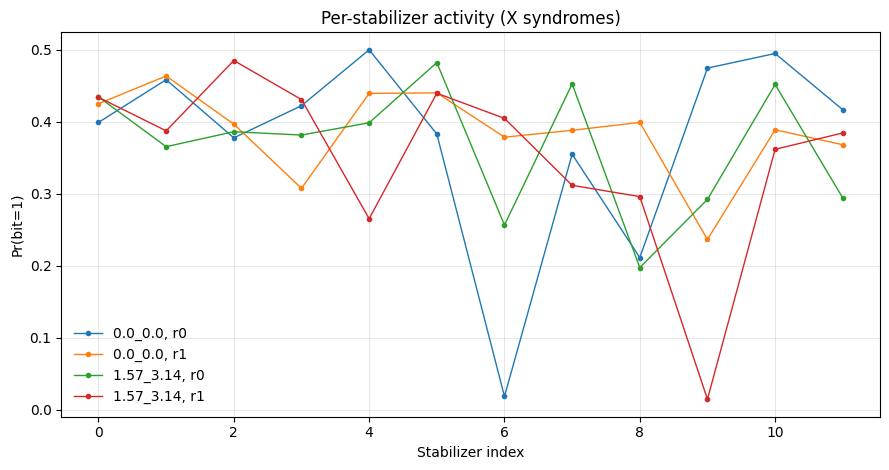


Top 10 per-stabilizer differences for Z: 0.0_0.0 (r0 vs r1):
  idx=06: Δ=0.2900  (pA=0.4688, pB=0.1787)
  idx=00: Δ=0.2463  (pA=0.3738, pB=0.1274)
  idx=07: Δ=0.1687  (pA=0.3672, pB=0.1985)
  idx=10: Δ=0.1531  (pA=0.3374, pB=0.1843)
  idx=09: Δ=0.1445  (pA=0.4138, pB=0.2693)
  idx=03: Δ=0.1353  (pA=0.1936, pB=0.3289)
  idx=01: Δ=0.1335  (pA=0.2820, pB=0.4155)
  idx=02: Δ=0.0916  (pA=0.3145, pB=0.4060)
  idx=08: Δ=0.0522  (pA=0.3953, pB=0.3430)
  idx=04: Δ=0.0229  (pA=0.4570, pB=0.4341)

Top 10 per-stabilizer differences for Z: 1.57_3.14 (r0 vs r1):
  idx=09: Δ=0.1704  (pA=0.4636, pB=0.2932)
  idx=04: Δ=0.1619  (pA=0.1213, pB=0.2832)
  idx=01: Δ=0.1589  (pA=0.2268, pB=0.3857)
  idx=07: Δ=0.1458  (pA=0.3708, pB=0.2251)
  idx=06: Δ=0.0847  (pA=0.4004, pB=0.3157)
  idx=08: Δ=0.0811  (pA=0.3035, pB=0.2224)
  idx=02: Δ=0.0725  (pA=0.4114, pB=0.3389)
  idx=10: Δ=0.0706  (pA=0.3335, pB=0.2629)
  idx=03: Δ=0.0552  (pA=0.3069, pB=0.3621)
  idx=05: Δ=0.0396  (pA=0.3240, pB=0.3635)

Top 10 per-st

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# --------- helpers ---------
def bits_matrix(series):
    """Convert a pandas Series of equal-length '0/1' strings into an (n, L) uint8 matrix."""
    s0 = series.iloc[0]
    L = len(s0)
    # fast vectorized split: turn list of strings -> array of chars -> 0/1 ints
    arr = np.frombuffer(("".join(series.values)).encode("ascii"), dtype="S1").reshape(len(series), L)
    return (arr == b"1").astype(np.uint8)

def per_stabilizer_p(df_subset, col):
    """Return per-bit Pr(bit=1) for a subset and column 'syndrome_Z' or 'syndrome_X'."""
    M = bits_matrix(df_subset[col])
    return M.mean(axis=0)

def lineplot_four(ax, x, curves, title, ylabel):
    for label, y in curves.items():
        ax.plot(x, y, marker="o", ms=3, lw=1, label=label)
    ax.set_xlabel("Stabilizer index")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.3)

def top_differences(name, a, b, k=8):
    """Print top-|a-b| indices."""
    d = np.abs(a - b)
    idx = np.argsort(d)[::-1][:k]
    print(f"\nTop {k} per-stabilizer differences for {name}:")
    for i in idx:
        print(f"  idx={i:02d}: Δ={d[i]:.4f}  (pA={a[i]:.4f}, pB={b[i]:.4f})")

# --------- choose your states ---------
state1 = "0.0_0.0"
state2 = "1.57_3.14"

# subsets
s1r0 = df[(df["state_id"] == state1) & (df["round"] == 0)]
s1r1 = df[(df["state_id"] == state1) & (df["round"] == 1)]
s2r0 = df[(df["state_id"] == state2) & (df["round"] == 0)]
s2r1 = df[(df["state_id"] == state2) & (df["round"] == 1)]

# sanity checks: constant lengths and non-empty
for name, sub in [("s1r0", s1r0), ("s1r1", s1r1), ("s2r0", s2r0), ("s2r1", s2r1)]:
    assert len(sub) > 0, f"{name} is empty"
    assert sub["syndrome_Z"].str.len().nunique() == 1, f"{name}: variable Z length"
    assert sub["syndrome_X"].str.len().nunique() == 1, f"{name}: variable X length"

# per-stabilizer probabilities
pZ_s1r0 = per_stabilizer_p(s1r0, "syndrome_Z")
pZ_s1r1 = per_stabilizer_p(s1r1, "syndrome_Z")
pZ_s2r0 = per_stabilizer_p(s2r0, "syndrome_Z")
pZ_s2r1 = per_stabilizer_p(s2r1, "syndrome_Z")

pX_s1r0 = per_stabilizer_p(s1r0, "syndrome_X")
pX_s1r1 = per_stabilizer_p(s1r1, "syndrome_X")
pX_s2r0 = per_stabilizer_p(s2r0, "syndrome_X")
pX_s2r1 = per_stabilizer_p(s2r1, "syndrome_X")

# ------- plots: Z then X (two separate figures) -------
xZ = np.arange(len(pZ_s1r0))
figZ, axZ = plt.subplots(figsize=(9,4.8))
curvesZ = OrderedDict({
    f"{state1}, r0": pZ_s1r0,
    f"{state1}, r1": pZ_s1r1,
    f"{state2}, r0": pZ_s2r0,
    f"{state2}, r1": pZ_s2r1,
})
lineplot_four(axZ, xZ, curvesZ, "Per-stabilizer activity (Z syndromes)", "Pr(bit=1)")
plt.tight_layout()
plt.show()

xX = np.arange(len(pX_s1r0))
figX, axX = plt.subplots(figsize=(9,4.8))
curvesX = OrderedDict({
    f"{state1}, r0": pX_s1r0,
    f"{state1}, r1": pX_s1r1,
    f"{state2}, r0": pX_s2r0,
    f"{state2}, r1": pX_s2r1,
})
lineplot_four(axX, xX, curvesX, "Per-stabilizer activity (X syndromes)", "Pr(bit=1)")
plt.tight_layout()
plt.show()

# ------- quick quantitative summaries -------
# within-state drift (r0 vs r1)
top_differences(f"Z: {state1} (r0 vs r1)", pZ_s1r0, pZ_s1r1, k=10)
top_differences(f"Z: {state2} (r0 vs r1)", pZ_s2r0, pZ_s2r1, k=10)
top_differences(f"X: {state1} (r0 vs r1)", pX_s1r0, pX_s1r1, k=10)
top_differences(f"X: {state2} (r0 vs r1)", pX_s2r0, pX_s2r1, k=10)

# between-state separation (same round)
top_differences(f"Z: {state1} vs {state2} (round 0)", pZ_s1r0, pZ_s2r0, k=10)
top_differences(f"Z: {state1} vs {state2} (round 1)", pZ_s1r1, pZ_s2r1, k=10)
top_differences(f"X: {state1} vs {state2} (round 0)", pX_s1r0, pX_s2r0, k=10)
top_differences(f"X: {state1} vs {state2} (round 1)", pX_s1r1, pX_s2r1, k=10)


In [30]:
from scipy.spatial.distance import jensenshannon
import numpy as np

def syndrome_distribution(df, col):
    counts = df[col].value_counts(normalize=True)
    return counts

def js_divergence(p, q):
    # ensure aligned indices
    union = p.index.union(q.index)
    p = p.reindex(union, fill_value=0)
    q = q.reindex(union, fill_value=0)
    return jensenshannon(p, q)

# Example: compare within one state
state = "0.0_0.0"
p = syndrome_distribution(df[(df.state_id == state) & (df['round'] == 0)], "syndrome")
q = syndrome_distribution(df[(df.state_id == state) & (df['round'] == 1)], "syndrome")

js_same = js_divergence(p, q)
print("JS divergence (same state, diff rounds):", js_same)


JS divergence (same state, diff rounds): 0.8315376880822397


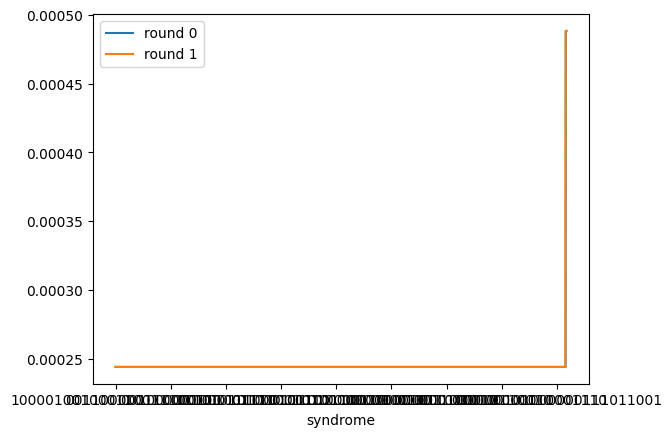

In [28]:
import matplotlib.pyplot as plt
p.sort_values().plot(label="round 0")
q.sort_values().plot(label="round 1")
plt.legend(); plt.show()


In [ ]:
for r in [0, 1]:
    print(r, df[df["round"]==r]["syndrome"].nunique())

s0 = set(df[df["round"]==0]["syndrome"])
s1 = set(df[df["round"]==1]["syndrome"])
print("Shared syndromes:", len(s0 & s1))
print("Unique to round 0:", len(s0 - s1))
print("Unique to round 1:", len(s1 - s0))


0 16298
1 16281
Shared syndromes: 132
Unique to round 0: 16166
Unique to round 1: 16149


In [ ]:
p = syndrome_distribution(df[(df.state_id == "0.0_0.0") & (df.round == 0)], "syndrome")
q = syndrome_distribution(df[(df.state_id == "1.57_3.14") & (df.round == 0)], "syndrome")
print(js_divergence(p, q))

0.8316010335627361
